# Práctica 2 — Generación de Variables Aleatorias Continuas
**CC2017 Modelación y Simulación — Ciclo 2, 2026**

Notebook único de solución y verificación numérica. Todas las simulaciones usan una semilla global reproducible. Cada estimación Monte Carlo se contrasta contra su valor exacto —forma cerrada cuando existe, cuadratura de alta precisión en caso contrario— y se reporta la desviación en unidades de error estándar.

## 0. Configuración común

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, optimize, special, stats
from IPython.display import display

SEMILLA = 20_172_026
rng = np.random.default_rng(SEMILLA)

NAVY = "#003865"
ORANGE = "#FC4C02"
GREY = "#696969"
YELLOW = "#FDB92E"
PALETA = [NAVY, ORANGE, GREY, YELLOW]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


def tabla(df, decimales=6):
    # Tabla uniforme, sin índice, con formato numérico homogéneo.
    return df.style.hide(axis="index").format(precision=decimales, thousands=",")


def z_desviacion(estimacion, exacto, se):
    return (estimacion - exacto) / se if se > 0 else np.nan


def se_media(x):
    x = np.asarray(x, dtype=float)
    return x.std(ddof=1) / np.sqrt(x.size)


def se_proporcion(p_hat, n):
    return math.sqrt(p_hat * (1 - p_hat) / n)

print(f"Semilla global: {SEMILLA}")

Semilla global: 20172026


## 1. Ejercicio 1

**Enunciado.** Sea $X\sim\text{Exp}(1)$. Simular la condicional de $X$ dado $X<0.05$, cuya densidad es
$$f(x)=\frac{e^{-x}}{1-e^{-0.05}},\qquad 0<x<0.05 .$$
Generar 1000 variables y estimar $E[X\mid X<0.05]$; luego obtener el valor exacto.

**Método.** El camino ingenuo —generar exponenciales y descartar las que superen $0.05$— acepta con probabilidad $1-e^{-0.05}=0.04877$, es decir **20.5 exponenciales por variable aceptada**. En su lugar se usa transformación inversa sobre la condicional, que es exacta y cuesta **un solo uniforme**:
$$F(x)=\frac{1-e^{-x}}{1-e^{-0.05}}\ \Longrightarrow\ X=F^{-1}(U)=-\log\!\bigl(1-U(1-e^{-0.05})\bigr).$$

**Valor exacto.** Integrando por partes en $\int_0^a x e^{-x}dx=1-(1+a)e^{-a}$ con $a=0.05$:
$$E[X\mid X<a]=\frac{1-(1+a)e^{-a}}{1-e^{-a}} .$$

In [2]:
A1 = 0.05
NORM1 = 1 - math.exp(-A1)   # 1 - e^{-0.05}


def generar_ej1(n):
    # Transformación inversa de la exponencial truncada: 1 uniforme por variable.
    u = rng.random(n)
    return -np.log(1 - u * NORM1)

# Valor exacto y su confirmación por cuadratura de alta precisión.
exacto1 = (1 - (1 + A1) * math.exp(-A1)) / NORM1
quad1 = integrate.quad(lambda x: x * math.exp(-x), 0, A1, epsabs=1e-16, epsrel=1e-16)[0] / NORM1
assert abs(exacto1 - quad1) < 1e-12

# Las 1000 variables que pide el enunciado.
X1 = generar_ej1(1_000)
assert np.all((X1 > 0) & (X1 < A1))   # el soporte se respeta por construcción, sin rechazo

est1, se1 = X1.mean(), se_media(X1)

# Convergencia y contraste con corridas mayores.
filas = []
X1_grande = np.concatenate([X1, generar_ej1(499_000)])
for r in [1_000, 10_000, 100_000, 500_000]:
    x = X1_grande[:r]
    e, s = x.mean(), se_media(x)
    filas.append({"r": r, "Estimación MC": e, "SE": s, "Exacto": exacto1,
                  "Desviación (SE)": z_desviacion(e, exacto1, s)})
conv1 = pd.DataFrame(filas)
display(tabla(conv1, 8))

# Costo del método inverso frente al de rechazo: medido y exacto.
M1 = 1_000_000
propuestas = rng.exponential(1.0, size=M1)
n_aceptadas = np.count_nonzero(propuestas < A1)
costo_medido = M1 / n_aceptadas          # exponenciales gastadas por variable aceptada
costo_exacto = 1 / NORM1

costo1 = pd.DataFrame([
    {"Método": "Inversa truncada", "Sorteos por variable (medido)": 1.0,
     "Sorteos por variable (exacto)": 1.0, "Tasa de aceptación": 1.0},
    {"Método": "Rechazo sobre Exp(1)", "Sorteos por variable (medido)": costo_medido,
     "Sorteos por variable (exacto)": costo_exacto, "Tasa de aceptación": NORM1},
])
display(tabla(costo1, 4))

# Bondad de ajuste contra la CDF condicional exacta.
ks1 = stats.kstest(X1_grande, lambda x: (1 - np.exp(-x)) / NORM1)
print(f"KS contra F condicional: D = {ks1.statistic:.6f}, p = {ks1.pvalue:.4f}")

r,Estimación MC,SE,Exacto,Desviación (SE)
"1,000",0.02472690,0.00045849,0.02479168,-0.14127626
"10,000",0.02480315,0.00014344,0.02479168,0.07997535
"100,000",0.02479209,0.00004568,0.02479168,0.00899526
"500,000",0.02477018,0.00002040,0.02479168,-1.05336542


Método,Sorteos por variable (medido),Sorteos por variable (exacto),Tasa de aceptación
Inversa truncada,1.0000,1.0000,1.0000
Rechazo sobre Exp(1),20.4269,20.5042,0.0488


KS contra F condicional: D = 0.001233, p = 0.4325


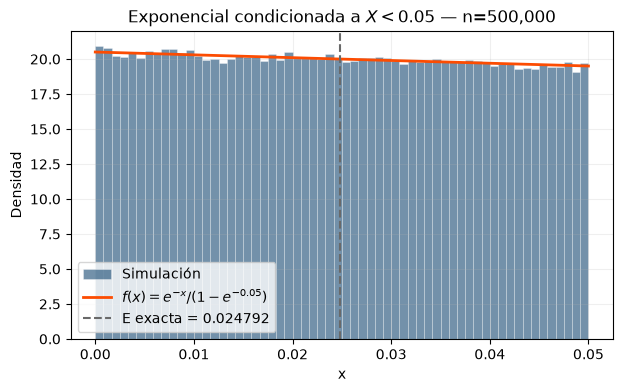

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(X1_grande, bins=60, density=True, color=NAVY, alpha=.55,
        edgecolor="white", linewidth=.4, label="Simulación")
xs = np.linspace(0, A1, 400)
ax.plot(xs, np.exp(-xs) / NORM1, linewidth=2, color=ORANGE, label=r"$f(x)=e^{-x}/(1-e^{-0.05})$")
ax.axvline(exacto1, linestyle="--", color=GREY, label=f"E exacta = {exacto1:.6f}")
ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.set_title(f"Exponencial condicionada a $X<0.05$ — n={X1_grande.size:,}")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Respuesta

**Algoritmo eficiente.** Generar $U\sim\text{Unif}(0,1)$ y devolver $X=-\log\bigl(1-U(1-e^{-0.05})\bigr)$: un uniforme, sin rechazo, contra las $1/(1-e^{-0.05})=\mathbf{20.5}$ exponenciales que exigiría truncar por rechazo.

**Valor exacto.**
$$\boxed{E[X\mid X<0.05]=\frac{1-1.05\,e^{-0.05}}{1-e^{-0.05}}=0.0247916753\ldots}$$

La estimación con las 1000 variables aparece en la primera fila de la tabla de convergencia, junto con su error estándar y su desviación respecto al valor exacto. Nótese que el valor está apenas por debajo de $a/2=0.025$: en un intervalo tan corto la densidad exponencial es casi uniforme.

## 2. Ejercicio 2 — Método de composición

**Enunciado.** Si es fácil generar de cada $F_i$, ¿cómo generar $X$ con
$$F(x)=\sum_{i=1}^{n}p_iF_i(x),\qquad p_i\ge 0,\ \sum_i p_i=1\ ?$$

**Método.** Se interpreta la mezcla como un experimento en dos etapas. Sea $I$ una variable **discreta** con $P(I=i)=p_i$, y dado $I=i$ genérese $X\sim F_i$. Entonces, condicionando en $I$,
$$P(X\le x)=\sum_{i=1}^{n}P(X\le x\mid I=i)\,P(I=i)=\sum_{i=1}^{n}p_iF_i(x)=F(x),$$
que es exactamente la distribución buscada.

**Algoritmo.**

- **Paso 1:** genere $I$ con $P(I=i)=p_i$ (transformación inversa discreta sobre las $p_i$ acumuladas: un uniforme $U_1$).
- **Paso 2:** genere $X\sim F_{I}$ con el método que corresponda a esa componente (un segundo uniforme $U_2$).
- **Paso 3:** devuelva $X$.

El costo es **dos uniformes por variable** y no hay rechazo: toda variable generada se acepta. La utilidad del método es que descompone una $F$ complicada en piezas $F_i$ cada una trivial de invertir.

In [4]:
def generar_composicion(pesos, generadores, n):
    """Paso 1: sortear la componente I con P(I=i)=p_i. Paso 2: generar de F_I."""
    pesos = np.asarray(pesos, dtype=float)
    assert np.isclose(pesos.sum(), 1.0) and np.all(pesos >= 0)
    assert len(pesos) == len(generadores)

    # Paso 1: inversa discreta sobre la acumulada de los pesos.
    cdf = np.round(np.cumsum(pesos), 12)
    idx = np.searchsorted(cdf, rng.random(n), side="left")

    # Paso 2: cada componente se llena en bloque con su propio generador.
    x = np.empty(n, dtype=float)
    for i, gen in enumerate(generadores):
        m = np.count_nonzero(idx == i)
        if m:
            x[idx == i] = gen(m)
    return x

# Verificación del argumento: la frecuencia empírica de I reproduce p_i y la
# mezcla resultante reproduce sum(p_i F_i) punto a punto.
pesos_demo = np.array([0.5, 0.3, 0.2])
Fs_demo = [lambda x: 1 - np.exp(-x),                       # Exp(1)
           lambda x: np.clip(x / 2, 0, 1),                  # Unif(0,2)
           lambda x: stats.gamma.cdf(x, a=3, scale=1.0)]    # Gamma(3,1)
gens_demo = [lambda m: rng.exponential(1.0, m),
             lambda m: rng.uniform(0, 2, m),
             lambda m: rng.gamma(3.0, 1.0, m)]

X2 = generar_composicion(pesos_demo, gens_demo, 400_000)
rejilla = np.linspace(0.05, 8, 12)
F_mezcla = sum(p * F(rejilla) for p, F in zip(pesos_demo, Fs_demo))
F_emp = np.array([(X2 <= x).mean() for x in rejilla])
se_emp = np.sqrt(F_emp * (1 - F_emp) / X2.size)

res2 = pd.DataFrame({"x": rejilla, "F empírica": F_emp, "SE": se_emp,
                     "sum p_i F_i(x)": F_mezcla,
                     "Desviación (SE)": (F_emp - F_mezcla) / se_emp})
display(tabla(res2, 6))
assert np.max(np.abs(res2["Desviación (SE)"])) < 4

x,F empírica,SE,sum p_i F_i(x),Desviación (SE)
0.050000,0.031727,0.000277,0.031889,-0.583842
0.772727,0.393600,0.000772,0.393749,-0.193458
1.495455,0.650617,0.000754,0.650247,0.490896
2.218182,0.822585,0.000604,0.822028,0.921963
2.940909,0.886827,0.000501,0.886279,1.094060
3.663636,0.928925,0.000406,0.928853,0.177857
4.386364,0.956372,0.000323,0.956423,-0.157170
5.109091,0.973853,0.000252,0.973827,0.099848
5.831818,0.984645,0.000194,0.984552,0.477518
6.554545,0.991088,0.000149,0.991021,0.447490


### Respuesta

Generar primero la **etiqueta** $I$ con $P(I=i)=p_i$ y después $X\sim F_I$. Condicionando en $I$ se obtiene $P(X\le x)=\sum_i p_iF_i(x)=F(x)$, de modo que
$$\boxed{X\sim F \iff X\mid I=i\ \sim F_i,\quad P(I=i)=p_i.}$$
Cuesta dos uniformes y no rechaza nada. La tabla confirma la igualdad: la CDF empírica coincide con $\sum_i p_iF_i$ dentro del error Monte Carlo en toda la rejilla.

## 3. Ejercicio 3 — Aplicaciones de la composición

La observación que resuelve los tres incisos es que, para $F_i(x)=x^{i}$ en $[0,1]$, la inversa es inmediata:
$$U=X^{i}\ \Longrightarrow\ X=U^{1/i},$$
es decir, $U^{1/i}$ es el **máximo de $i$ uniformes** independientes.

**(a)** $F(x)=\dfrac{x+x^3+x^5}{3}$ es la mezcla de $x$, $x^3$ y $x^5$ con pesos $\tfrac13$ cada uno:
$$p=(\tfrac13,\tfrac13,\tfrac13),\qquad X=U^{1},\ U^{1/3},\ U^{1/5}.$$
Media exacta: $E[X]=\tfrac13\left(\tfrac12+\tfrac34+\tfrac56\right)=\tfrac{25}{36}$.

**(b)** Separando la $F$ por partes,
$$F(x)=\tfrac13\underbrace{(1-e^{-2x})}_{\text{Exp}(2)}+\tfrac23\underbrace{\min(x,1)}_{\text{Unif}(0,1)},$$
lo que se comprueba en ambos tramos: para $0<x<1$ da $\frac{1-e^{-2x}+2x}{3}$, y para $x>1$ da $\frac{1-e^{-2x}+2}{3}=\frac{3-e^{-2x}}{3}$. Entonces con probabilidad $\tfrac13$ se genera $-\tfrac12\log U$ y con probabilidad $\tfrac23$ se genera $U$. Media exacta: $E[X]=\tfrac13\cdot\tfrac12+\tfrac23\cdot\tfrac12=\tfrac12$.

**(c)** $F(x)=\sum_i \alpha_i x^i$ con $\alpha_i\ge0$ y $\sum_i\alpha_i=1$ ya está escrita como mezcla: se sortea $i$ con probabilidad $\alpha_i$ y se devuelve $U^{1/i}$. Media exacta: $E[X]=\sum_i\alpha_i\frac{i}{i+1}$. Los incisos (a) y (b) del polinomio son el caso particular $\alpha=(\tfrac13,0,\tfrac13,0,\tfrac13)$.

In [5]:
N3 = 400_000

# --- (a) F(x) = (x + x^3 + x^5)/3 --------------------------------------------
pot_a = np.array([1, 3, 5])
pesos_a = np.full(3, 1 / 3)
gens_a = [(lambda i: (lambda m: rng.random(m) ** (1 / i)))(i) for i in pot_a]
Xa = generar_composicion(pesos_a, gens_a, N3)
Fa = lambda x: (np.asarray(x, float) + np.asarray(x, float) ** 3 + np.asarray(x, float) ** 5) / 3
media_a = np.sum(pesos_a * pot_a / (pot_a + 1))
assert np.isclose(media_a, 25 / 36)

# --- (b) mezcla de Exp(2) y Unif(0,1) ----------------------------------------
pesos_b = np.array([1 / 3, 2 / 3])
gens_b = [lambda m: rng.exponential(0.5, m), lambda m: rng.random(m)]
Xb = generar_composicion(pesos_b, gens_b, N3)
def Fb(x):
    x = np.asarray(x, float)
    return np.where(x < 1, (1 - np.exp(-2 * x) + 2 * x) / 3, (3 - np.exp(-2 * x)) / 3)
# La descomposición debe reproducir la F del enunciado en ambos tramos.
_x = np.linspace(0, 8, 20_001)
assert np.max(np.abs(Fb(_x) - ((1 / 3) * (1 - np.exp(-2 * _x)) + (2 / 3) * np.minimum(_x, 1.0)))) < 1e-12
media_b = 0.5

# --- (c) F(x) = sum alpha_i x^i ----------------------------------------------
alpha = np.array([0.15, 0.25, 0.10, 0.30, 0.20])
pot_c = np.arange(1, len(alpha) + 1)
assert np.isclose(alpha.sum(), 1.0) and np.all(alpha >= 0)
gens_c = [(lambda i: (lambda m: rng.random(m) ** (1 / i)))(i) for i in pot_c]
Xc = generar_composicion(alpha, gens_c, N3)
Fc = lambda x: sum(a * np.asarray(x, float) ** i for a, i in zip(alpha, pot_c))
media_c = np.sum(alpha * pot_c / (pot_c + 1))

filas = []
for nombre, X, F, exacto in [("(a) (x+x^3+x^5)/3", Xa, Fa, media_a),
                             ("(b) Exp(2) + Unif(0,1)", Xb, Fb, media_b),
                             ("(c) sum alpha_i x^i", Xc, Fc, media_c)]:
    est, se = X.mean(), se_media(X)
    ks = stats.kstest(X, F)
    filas.append({"Inciso": nombre, "E[X] MC": est, "SE": se, "E[X] exacto": exacto,
                  "Desviación (SE)": z_desviacion(est, exacto, se),
                  "KS D": ks.statistic, "KS p": ks.pvalue})
res3 = pd.DataFrame(filas)
display(tabla(res3, 6))
assert np.all(res3["KS p"] > 0.01)

Inciso,E[X] MC,SE,E[X] exacto,Desviación (SE),KS D,KS p
(a) (x+x^3+x^5)/3,0.694784,0.000409,0.694444,0.831145,0.001604,0.254592
"(b) Exp(2) + Unif(0,1)",0.500694,0.000591,0.500000,1.173969,0.000879,0.916705
(c) sum alpha_i x^i,0.723872,0.000369,0.723333,1.460903,0.001264,0.544560


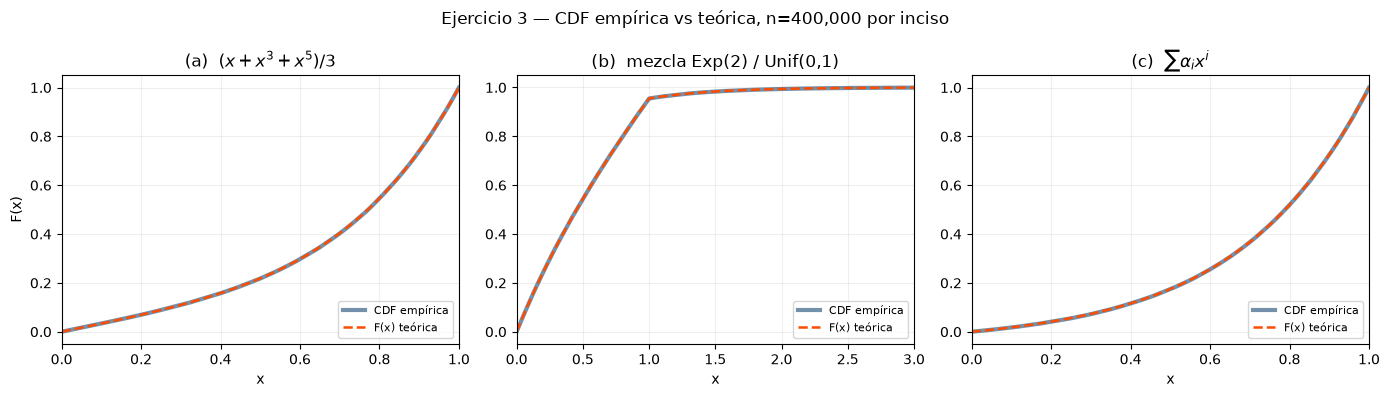

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
paneles = [("(a)  $(x+x^3+x^5)/3$", Xa, Fa, 0, 1),
           ("(b)  mezcla Exp(2) / Unif(0,1)", Xb, Fb, 0, 3),
           ("(c)  $\\sum\\alpha_i x^i$", Xc, Fc, 0, 1)]
for ax, (titulo, X, F, lo, hi) in zip(axes, paneles):
    xs = np.linspace(lo, hi, 500)
    Xo = np.sort(X)
    emp = np.arange(1, Xo.size + 1) / Xo.size
    paso = max(1, Xo.size // 2000)
    ax.plot(Xo[::paso], emp[::paso], linewidth=3, alpha=.55, color=NAVY, label="CDF empírica")
    ax.plot(xs, F(xs), linestyle="--", linewidth=1.8, color=ORANGE, label="F(x) teórica")
    ax.set_xlim(lo, hi)
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.grid(alpha=.2)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("F(x)")
fig.suptitle(f"Ejercicio 3 — CDF empírica vs teórica, n={N3:,} por inciso")
plt.tight_layout()
plt.show()

### Respuesta

**(a)** Sortear $i\in\{1,3,5\}$ con probabilidad $\tfrac13$ cada uno y devolver $\boxed{X=U^{1/i}}$. Media exacta $E[X]=\tfrac{25}{36}=0.6944\overline{4}$.

**(b)** Con probabilidad $\tfrac13$ devolver una $\text{Exp}(2)$, es decir $\boxed{X=-\tfrac12\log U}$; con probabilidad $\tfrac23$ devolver $\boxed{X=U}$. Media exacta $E[X]=\tfrac12$.

**(c)** Sortear $i$ con probabilidad $\alpha_i$ y devolver $\boxed{X=U^{1/i}}$, el máximo de $i$ uniformes. Media exacta $E[X]=\sum_i\alpha_i\frac{i}{i+1}$; con el $\alpha$ concreto usado arriba vale $0.723\overline{3}$.

En los tres casos la media Monte Carlo cae dentro del error estándar del valor exacto y la prueba de Kolmogórov–Smirnov contra la $F$ del enunciado no se rechaza, lo que confirma que la mezcla generada es la distribución pedida y no sólo comparte su media.

## 4. Ejercicio 4 — Riesgo agregado de una cartera de seguros

**Enunciado.** $M=1000$ asegurados; cada uno reclama el próximo mes de forma independiente con probabilidad $p=0.05$. Los montos son $\text{Exp}$ de media $\$800$ e independientes. Estimar por simulación
$$P(S>50{,}000),\qquad S=\sum_{k=1}^{M}I_k\,C_k .$$

**Método.** Dos hechos exactos permiten simular sin recorrer los 1000 asegurados uno por uno:

1. $N=\sum_k I_k\sim\text{Binomial}(1000,\,0.05)$, porque los $I_k$ son Bernoulli independientes con la misma $p$.
2. Dado $N=n$, la suma de $n$ exponenciales i.i.d. de media $\mu$ es exactamente $\text{Gamma}(n,\,\mu)$.

Por tanto cada réplica cuesta **dos sorteos** (una binomial y una gamma) en vez de 2000. Ambos pasos son exactos, no aproximaciones; el notebook lo verifica contra una simulación literal asegurado por asegurado.

**Valor exacto.** Condicionando en $N$,
$$P(S>c)=\sum_{n=1}^{M}\binom{M}{n}p^{n}(1-p)^{M-n}\;P\bigl(\text{Gamma}(n,\mu)>c\bigr),$$
suma finita evaluable a precisión de máquina. Como referencia, $E[S]=Mp\mu=\$40{,}000$ y
$$\operatorname{Var}(S)=E[N]\operatorname{Var}(C)+\operatorname{Var}(N)E[C]^2=50(800^2)+47.5(800^2)=62{,}400{,}000,$$
de donde $\sigma_S=\$7{,}899.37$ y el umbral queda a $1.266\sigma$ de la media.

In [7]:
M4, P4, MU4, UMBRAL4 = 1_000, 0.05, 800.0, 50_000.0

# --- Valor exacto: mezcla binomial de colas gamma -----------------------------
n_grid = np.arange(0, M4 + 1)
pmf_N = stats.binom.pmf(n_grid, M4, P4)
cola_gamma = np.where(n_grid == 0, 0.0,
                      stats.gamma.sf(UMBRAL4, a=np.maximum(n_grid, 1), scale=MU4))
exacto4 = float(np.sum(pmf_N * cola_gamma))
assert np.isclose(pmf_N.sum(), 1.0)

ES4 = M4 * P4 * MU4
VarS4 = M4 * P4 * (2 * MU4**2) - M4 * (P4 * MU4) ** 2   # ley de varianza total
assert np.isclose(VarS4, 50 * MU4**2 + 47.5 * MU4**2)
sdS4 = math.sqrt(VarS4)

# --- Simulación eficiente: N binomial, luego una gamma ------------------------
R4 = 400_000
N4 = rng.binomial(M4, P4, R4)
S4 = np.where(N4 > 0, rng.gamma(np.maximum(N4, 1), MU4, R4), 0.0)
p4 = (S4 > UMBRAL4).mean()
se4 = se_proporcion(p4, R4)

# --- Simulación literal: 1000 asegurados por réplica, por bloques -------------
R4_lit, BLOQUE = 40_000, 4_000
excede_lit, S_lit_media = 0, 0.0
for inicio in range(0, R4_lit, BLOQUE):
    ind = rng.random((BLOQUE, M4)) < P4                 # I_k por asegurado
    montos = rng.exponential(MU4, size=(BLOQUE, M4))    # C_k por asegurado
    s = (ind * montos).sum(axis=1)
    excede_lit += np.count_nonzero(s > UMBRAL4)
    S_lit_media += s.sum()
p4_lit = excede_lit / R4_lit
se4_lit = se_proporcion(p4_lit, R4_lit)
S_lit_media /= R4_lit

# --- Aproximación normal, para dimensionar el sesgo por asimetría -------------
p4_normal = float(stats.norm.sf(UMBRAL4, ES4, sdS4))

res4 = pd.DataFrame([
    {"Método": f"Binomial-Gamma (R={R4:,})", "P(S>50,000)": p4, "SE": se4,
     "Exacto": exacto4, "Desviación (SE)": z_desviacion(p4, exacto4, se4)},
    {"Método": f"Literal, 1000 asegurados (R={R4_lit:,})", "P(S>50,000)": p4_lit, "SE": se4_lit,
     "Exacto": exacto4, "Desviación (SE)": z_desviacion(p4_lit, exacto4, se4_lit)},
    {"Método": "Aproximación normal", "P(S>50,000)": p4_normal, "SE": np.nan,
     "Exacto": exacto4, "Desviación (SE)": np.nan},
])
display(tabla(res4, 6))

res4b = pd.DataFrame([
    {"Cantidad": "E[N]", "MC": N4.mean(), "SE": se_media(N4), "Exacto": M4 * P4},
    {"Cantidad": "E[S]", "MC": S4.mean(), "SE": se_media(S4), "Exacto": ES4},
    {"Cantidad": "sd(S)", "MC": S4.std(ddof=1), "SE": np.nan, "Exacto": sdS4},
    {"Cantidad": "E[S] simulación literal", "MC": S_lit_media, "SE": np.nan, "Exacto": ES4},
])
res4b["Desviación (SE)"] = [z_desviacion(r.MC, r.Exacto, r.SE) if np.isfinite(r.SE) else np.nan
                            for r in res4b.itertuples()]
display(tabla(res4b, 4))

Método,"P(S>50,000)",SE,Exacto,Desviación (SE)
"Binomial-Gamma (R=400,000)",0.106862,0.000488,0.107098,-0.481502
"Literal, 1000 asegurados (R=40,000)",0.108850,0.001557,0.107098,1.125249
Aproximación normal,0.102770,nan,0.107098,nan


Cantidad,MC,SE,Exacto,Desviación (SE)
E[N],50.0113,0.0109,50.0000,1.0395
E[S],"40,010.5814",12.4909,"40,000.0000",0.8471
sd(S),"7,899.9419",nan,"7,899.3671",nan
E[S] simulación literal,"39,975.7245",nan,"40,000.0000",nan


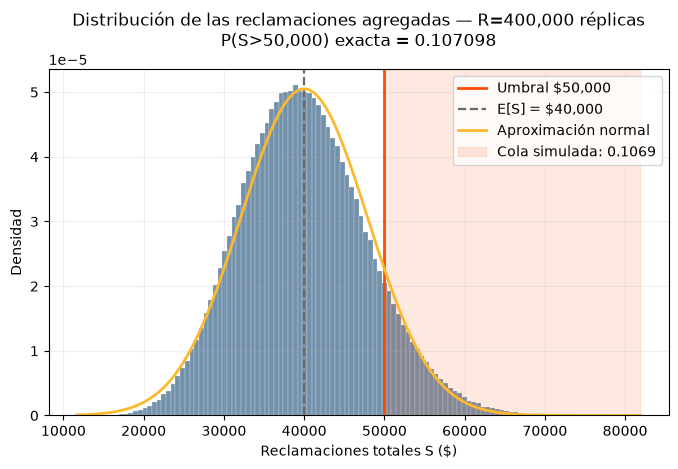

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(S4, bins=120, density=True, color=NAVY, alpha=.55, edgecolor="white", linewidth=.3)
ax.axvline(UMBRAL4, color=ORANGE, linewidth=2, label=f"Umbral \\$50,000")
ax.axvline(ES4, color=GREY, linestyle="--", linewidth=1.6, label=f"E[S] = \\${ES4:,.0f}")
xs = np.linspace(S4.min(), S4.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, ES4, sdS4), color=YELLOW, linewidth=2,
        label="Aproximación normal")
ax.axvspan(UMBRAL4, S4.max(), color=ORANGE, alpha=.12,
           label=f"Cola simulada: {p4:.4f}")
ax.set_xlabel("Reclamaciones totales S (\\$)")
ax.set_ylabel("Densidad")
ax.set_title(f"Distribución de las reclamaciones agregadas — R={R4:,} réplicas\n"
             f"P(S>50,000) exacta = {exacto4:.6f}")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Respuesta

$$\boxed{P(S>50{,}000)=0.10709770\ldots\approx 10.7\%}$$

Las dos simulaciones —la eficiente Binomial–Gamma con 400,000 réplicas y la literal que recorre los 1000 asegurados— caen dentro del error Monte Carlo del valor exacto, lo que confirma que el atajo $S\mid N=n\sim\text{Gamma}(n,800)$ no introduce sesgo.

La aproximación normal da $10.28\%$ y **subestima** el riesgo: $S$ es una suma compuesta con cola derecha pesada, y precisamente en la cola es donde la aproximación falla. Ése es el argumento a favor de simular en lugar de recurrir al Teorema del Límite Central: el umbral de interés está a $1.27\sigma$ de la media, justo donde la asimetría pesa.

## 5. Ejercicio 5 — Normal por rechazo (Ejemplo 5f)

**Enunciado.** Programar la generación de normales por el método del Ejemplo 5f: rechazo con densidad auxiliar exponencial de tasa 1.

**Método.** El valor absoluto de una normal estándar tiene densidad $f(x)=\sqrt{2/\pi}\,e^{-x^2/2}$ en $(0,\infty)$. Tomando $g(x)=e^{-x}$,
$$\frac{f(x)}{g(x)}=\sqrt{2/\pi}\;e^{\,x-x^2/2}$$
se maximiza en $x=1$, de donde la constante de rechazo es
$$c=\sqrt{2e/\pi}=1.3154892\ldots,\qquad \frac{f(x)}{c\,g(x)}=\exp\!\Bigl\{-\tfrac{(x-1)^2}{2}\Bigr\}.$$

*Versión 1 (la del texto).* Paso 1: $Y\sim\text{Exp}(1)$. Paso 2: $U$ uniforme. Paso 3: si $U\le e^{-(Y-1)^2/2}$ hacer $X=Y$; si no, volver al Paso 1. Luego $Z=\pm X$ con signo equiprobable.

*Versión 2 (equivalente).* Como $-\log U\sim\text{Exp}(1)$, la condición $U\le e^{-(Y_1-1)^2/2}$ equivale a $Y_2\ge (Y_1-1)^2/2$ con $Y_2\sim\text{Exp}(1)$. Al aceptar, el **excedente** $Y=Y_2-(Y_1-1)^2/2$ vuelve a ser $\text{Exp}(1)$ y resulta independiente de $Z$: el algoritmo entrega una normal y, gratis, una exponencial.

**Costo exacto.** El número de iteraciones es geométrico de media $c$, así que la tasa de aceptación es $1/c=0.7601734\ldots$. La versión 2 gasta $2c$ exponenciales por normal, pero devuelve una como subproducto: **$2c-1=1.631$ exponenciales netas** y $c=1.315$ cuadrados por normal, que son las cifras citadas en el texto.

In [9]:
C5 = math.sqrt(2 * math.e / math.pi)          # constante de rechazo
assert abs(C5 - 1.3154892) < 1e-6


def _consumidas(acepta, k):
    """Propuestas realmente gastadas hasta lograr k aceptaciones dentro del bloque."""
    return int(np.flatnonzero(acepta)[k - 1]) + 1 if k else 0


def normal_rechazo_v1(n):
    """Versión 1: Exp(1) + uniforme de aceptación. Devuelve Z y las propuestas gastadas."""
    z = np.empty(n)
    llenos, propuestas = 0, 0
    while llenos < n:
        m = int((n - llenos) * C5 * 1.2) + 16
        Y = rng.exponential(1.0, m)                 # Paso 1
        U = rng.random(m)                           # Paso 2
        acepta = U <= np.exp(-((Y - 1) ** 2) / 2)   # Paso 3
        k = min(n - llenos, np.count_nonzero(acepta))
        propuestas += _consumidas(acepta, k)        # sólo lo usado, no el bloque entero
        X = Y[acepta][:k]
        signo = np.where(rng.random(k) <= 0.5, 1.0, -1.0)
        z[llenos:llenos + k] = signo * X
        llenos += k
    return z, propuestas


def normal_rechazo_v2(n):
    """Versión 2: dos exponenciales; el excedente es una Exp(1) independiente."""
    z = np.empty(n)
    extra = np.empty(n)
    llenos, propuestas = 0, 0
    while llenos < n:
        m = int((n - llenos) * C5 * 1.2) + 16
        Y1 = rng.exponential(1.0, m)                # Paso 1
        Y2 = rng.exponential(1.0, m)                # Paso 2
        W = Y2 - (Y1 - 1) ** 2 / 2                  # Paso 3
        acepta = W > 0
        k = min(n - llenos, np.count_nonzero(acepta))
        propuestas += _consumidas(acepta, k)
        Y1a, Wa = Y1[acepta][:k], W[acepta][:k]
        signo = np.where(rng.random(k) <= 0.5, 1.0, -1.0)   # Paso 4
        z[llenos:llenos + k] = signo * Y1a
        extra[llenos:llenos + k] = Wa
        llenos += k
    return z, extra, propuestas

N5 = 500_000
Z5_v1, prop_v1 = normal_rechazo_v1(N5)
Z5, Y5_extra, prop_v2 = normal_rechazo_v2(N5)

# --- Costo: propuestas (iteraciones) por normal aceptada ----------------------
it_v1, it_v2 = prop_v1 / N5, prop_v2 / N5
costo5 = pd.DataFrame([
    {"Versión": "1 — Exp(1) + U", "Iteraciones/normal MC": it_v1, "Iteraciones exactas": C5,
     "Aceptación MC": 1 / it_v1, "Aceptación exacta": 1 / C5,
     "Exponenciales netas MC": it_v1, "Exponenciales netas exactas": C5},
    {"Versión": "2 — dos Exp(1)", "Iteraciones/normal MC": it_v2, "Iteraciones exactas": C5,
     "Aceptación MC": 1 / it_v2, "Aceptación exacta": 1 / C5,
     "Exponenciales netas MC": 2 * it_v2 - 1, "Exponenciales netas exactas": 2 * C5 - 1},
])
display(tabla(costo5, 5))
assert np.all(np.abs(costo5["Iteraciones/normal MC"] - C5) < 0.01)

# --- La normal generada es efectivamente N(0,1) ------------------------------
filas = []
for nombre, Z in [("Versión 1", Z5_v1), ("Versión 2", Z5)]:
    m, s = Z.mean(), se_media(Z)
    ks = stats.kstest(Z, "norm")
    filas.append({"Muestra": nombre, "Media MC": m, "SE": s, "Media exacta": 0.0,
                  "Desviación (SE)": z_desviacion(m, 0.0, s),
                  "Varianza MC": Z.var(ddof=1), "Varianza exacta": 1.0,
                  "KS D": ks.statistic, "KS p": ks.pvalue})

# --- El excedente es Exp(1) e independiente de Z -----------------------------
ks_exp = stats.kstest(Y5_extra, "expon")
filas.append({"Muestra": "Subproducto Y ~ Exp(1)", "Media MC": Y5_extra.mean(),
              "SE": se_media(Y5_extra), "Media exacta": 1.0,
              "Desviación (SE)": z_desviacion(Y5_extra.mean(), 1.0, se_media(Y5_extra)),
              "Varianza MC": Y5_extra.var(ddof=1), "Varianza exacta": 1.0,
              "KS D": ks_exp.statistic, "KS p": ks_exp.pvalue})
res5 = pd.DataFrame(filas)
display(tabla(res5, 6))
assert np.all(res5["KS p"] > 0.01)

corr_zy = np.corrcoef(Z5, Y5_extra)[0, 1]
corr_ay = np.corrcoef(np.abs(Z5), Y5_extra)[0, 1]
se_corr = 1 / math.sqrt(N5)
print(f"corr(Z, Y)   = {corr_zy:+.6f}   ({corr_zy/se_corr:+.2f} SE de 0)")
print(f"corr(|Z|, Y) = {corr_ay:+.6f}   ({corr_ay/se_corr:+.2f} SE de 0)")

Versión,Iteraciones/normal MC,Iteraciones exactas,Aceptación MC,Aceptación exacta,Exponenciales netas MC,Exponenciales netas exactas
1 — Exp(1) + U,1.31565,1.31549,0.76008,0.76017,1.31565,1.31549
2 — dos Exp(1),1.31502,1.31549,0.76044,0.76017,1.63004,1.63098


Muestra,Media MC,SE,Media exacta,Desviación (SE),Varianza MC,Varianza exacta,KS D,KS p
Versión 1,0.001086,0.001415,0.000000,0.767833,1.000464,1.000000,0.001530,0.192296
Versión 2,-0.000491,0.001413,0.000000,-0.347854,0.997639,1.000000,0.000881,0.831762
Subproducto Y ~ Exp(1),1.000696,0.001415,1.000000,0.491804,1.000591,1.000000,0.001154,0.517423


corr(Z, Y)   = +0.001414   (+1.00 SE de 0)
corr(|Z|, Y) = -0.000534   (-0.38 SE de 0)


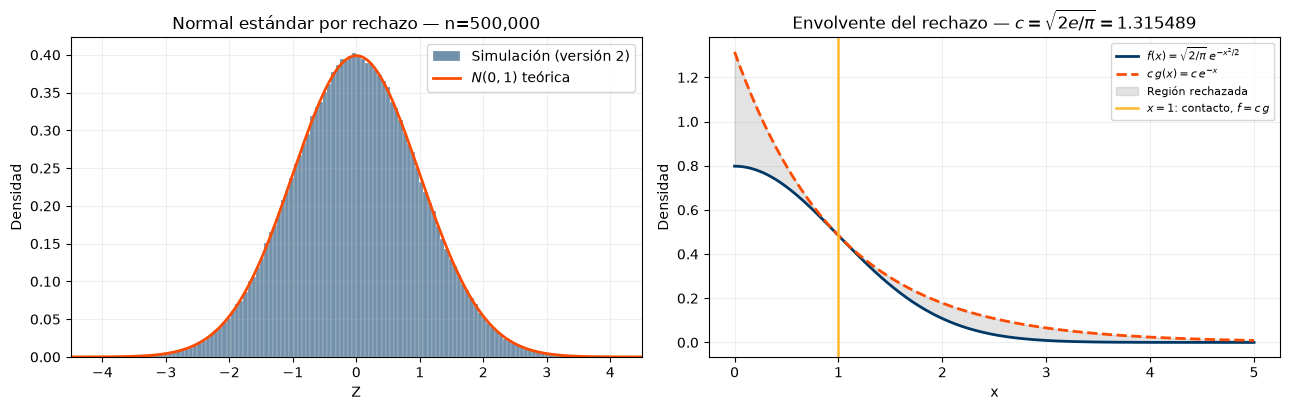

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(Z5, bins=140, density=True, color=NAVY, alpha=.55, edgecolor="white", linewidth=.3,
        label="Simulación (versión 2)")
xs = np.linspace(-4.5, 4.5, 500)
ax.plot(xs, stats.norm.pdf(xs), color=ORANGE, linewidth=2, label="$N(0,1)$ teórica")
ax.set_xlim(-4.5, 4.5)
ax.set_xlabel("Z")
ax.set_ylabel("Densidad")
ax.set_title(f"Normal estándar por rechazo — n={N5:,}")
ax.legend()
ax.grid(alpha=.2)

# El cociente f/(c g) es la probabilidad de aceptación en cada punto propuesto.
ax = axes[1]
xs = np.linspace(0, 5, 500)
ax.plot(xs, np.sqrt(2 / math.pi) * np.exp(-xs**2 / 2), color=NAVY, linewidth=2,
        label=r"$f(x)=\sqrt{2/\pi}\,e^{-x^2/2}$")
ax.plot(xs, C5 * np.exp(-xs), color=ORANGE, linewidth=2, linestyle="--",
        label=r"$c\,g(x)=c\,e^{-x}$")
ax.fill_between(xs, np.sqrt(2 / math.pi) * np.exp(-xs**2 / 2), C5 * np.exp(-xs),
                color=GREY, alpha=.18, label="Región rechazada")
ax.axvline(1.0, color=YELLOW, linewidth=1.8, label="$x=1$: contacto, $f=c\\,g$")
ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.set_title(f"Envolvente del rechazo — $c=\\sqrt{{2e/\\pi}}={C5:.6f}$")
ax.legend(fontsize=8)
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

### Respuesta

El programa está en las funciones `normal_rechazo_v1` y `normal_rechazo_v2`. Ambas producen normales estándar: la media no se separa de $0$ ni la varianza de $1$ más allá del error Monte Carlo, y la prueba KS contra $N(0,1)$ no se rechaza.

$$\boxed{c=\sqrt{2e/\pi}=1.3154892\ldots}\qquad\boxed{\text{tasa de aceptación}=1/c=0.7601734\ldots}$$

La versión 2 confirma además las dos afirmaciones del texto:

- el excedente $Y=Y_2-(Y_1-1)^2/2$ es $\text{Exp}(1)$ (KS no rechaza) e **independiente** de $Z$ —ambas correlaciones, con $Z$ y con $|Z|$, son nulas dentro de $\pm 2$ SE—, así que cada normal viene acompañada de una exponencial utilizable;
- el costo neto es $\boxed{2c-1=1.631}$ exponenciales y $c=1.315$ cuadrados por normal generada, que es lo que el texto redondea a 1.64 y 1.32.

La segunda gráfica muestra por qué el método funciona y por qué $c$ vale eso: $c\,e^{-x}$ domina a $f$ en todo el soporte y las toca en $x=1$; el área sombreada entre ambas curvas es exactamente la fracción rechazada, $1-1/c=24\%$.

## 6. Ejercicio 6 — Proceso de Poisson homogéneo

**Enunciado.** Programar la generación de las primeras $T$ unidades de tiempo de un proceso de Poisson de tasa $\lambda$.

**Método.** La caracterización operativa es que los **tiempos entre llegadas** son $\text{Exp}(\lambda)$ independientes. Por transformación inversa, $-\frac{1}{\lambda}\log U\sim\text{Exp}(\lambda)$, de modo que el algoritmo acumula esperas hasta rebasar el horizonte:

- **Paso 1:** $t=0$, lista de eventos vacía.
- **Paso 2:** genere $U$ y haga $t \leftarrow t-\frac{1}{\lambda}\log U$.
- **Paso 3:** si $t>T$, deténgase; si no, registre el evento en $t$ y vuelva al Paso 2.

**Propiedades exactas para verificar.** Con $\lambda=2$ y $T=10$:

- $N(T)\sim\text{Poisson}(\lambda T)$, de donde $E[N(T)]=\operatorname{Var}(N(T))=\lambda T=20$;
- los tiempos entre llegadas son $\text{Exp}(\lambda)$, con media $1/\lambda=0.5$;
- condicionado a $N(T)=n$, los $n$ tiempos de llegada se distribuyen como los **estadísticos de orden de $n$ uniformes** en $(0,T)$; equivalentemente, un tiempo tomado al azar entre ellos es $\text{Unif}(0,T)$.

**Advertencia sobre la verificación de las esperas.** Al contrastar los tiempos entre llegadas contra $\text{Exp}(\lambda)$ hay que usar **todas** las esperas que el algoritmo genera, incluida la última —la que rebasa $T$ y detiene el bucle—. Si se descartan sólo se conservan las esperas que *cupieron* dentro del horizonte, lo que elimina sistemáticamente las más largas: es censura por la derecha y sesga la media hacia abajo. El notebook calcula ambas versiones para exhibir el efecto.

In [11]:
LAM6, T6 = 2.0, 10.0


def poisson_homogeneo(lam, T, devolver_esperas=False):
    """Tiempos de evento en (0, T] de un Poisson de tasa lam.

    Con devolver_esperas=True entrega además TODAS las esperas generadas,
    incluida la última —la que rebasa T y provoca la parada—, que es la única
    colección que es i.i.d. Exp(lam).
    """
    eventos, esperas = [], []
    t = 0.0                                     # Paso 1
    while True:
        w = -math.log(rng.random()) / lam       # Paso 2: espera Exp(lam)
        esperas.append(w)
        t += w
        if t > T:                               # Paso 3
            return (np.array(eventos), np.array(esperas)) if devolver_esperas else np.array(eventos)
        eventos.append(t)

# Una realización de ejemplo.
camino6 = poisson_homogeneo(LAM6, T6)
print(f"Una realización: N(10) = {camino6.size} eventos")
print("Primeros tiempos:", np.round(camino6[:8], 4))

# Réplicas para contrastar contra la teoría.
R6 = 60_000
pares6 = [poisson_homogeneo(LAM6, T6, devolver_esperas=True) for _ in range(R6)]
caminos6 = [p[0] for p in pares6]
N6 = np.array([c.size for c in caminos6])
esperas6 = np.concatenate([p[1] for p in pares6])          # todas: i.i.d. Exp(lam)
esperas_internas6 = np.concatenate([p[1][:-1] for p in pares6 if p[1].size > 1])  # censuradas
tiempos6 = np.concatenate([c for c in caminos6 if c.size])

media_exacta = LAM6 * T6
res6 = pd.DataFrame([
    {"Cantidad": "E[N(T)]", "MC": N6.mean(), "SE": se_media(N6), "Exacto": media_exacta,
     "Desviación (SE)": z_desviacion(N6.mean(), media_exacta, se_media(N6))},
    {"Cantidad": "Var(N(T))", "MC": N6.var(ddof=1), "SE": np.nan, "Exacto": media_exacta,
     "Desviación (SE)": np.nan},
    {"Cantidad": "E[espera] (todas)", "MC": esperas6.mean(), "SE": se_media(esperas6),
     "Exacto": 1 / LAM6,
     "Desviación (SE)": z_desviacion(esperas6.mean(), 1 / LAM6, se_media(esperas6))},
    {"Cantidad": "E[espera] (sólo las que caben en T)", "MC": esperas_internas6.mean(),
     "SE": se_media(esperas_internas6), "Exacto": 1 / LAM6,
     "Desviación (SE)": z_desviacion(esperas_internas6.mean(), 1 / LAM6,
                                     se_media(esperas_internas6))},
])
display(tabla(res6, 6))

# Bondad de ajuste: conteos contra Poisson(20), esperas contra Exp(1/2),
# y uniformidad de los tiempos de llegada dentro del horizonte.
bordes = np.arange(N6.min(), N6.max() + 2)
obs = np.bincount(N6, minlength=bordes[-1])[bordes[:-1]]
esp = stats.poisson.pmf(bordes[:-1], media_exacta) * R6
junta = esp >= 5                                  # celdas con frecuencia esperada suficiente
obs_c = np.r_[obs[junta], obs[~junta].sum()]
esp_c = np.r_[esp[junta], esp[~junta].sum()]
esp_c = esp_c * obs_c.sum() / esp_c.sum()
chi2 = stats.chisquare(obs_c, esp_c, ddof=0)

ks_esperas = stats.kstest(esperas6, "expon", args=(0, 1 / LAM6))
ks_censurado = stats.kstest(esperas_internas6, "expon", args=(0, 1 / LAM6))
ks_unif = stats.kstest(tiempos6, "uniform", args=(0, T6))
print(f"Chi-cuadrado N(T) vs Poisson({media_exacta:.0f}):   X2 = {chi2.statistic:.2f}, p = {chi2.pvalue:.4f}")
print(f"KS todas las esperas vs Exp(1/{LAM6:.0f}):      D = {ks_esperas.statistic:.5f}, p = {ks_esperas.pvalue:.4f}")
print(f"KS sólo las que caben en T (sesgado):   D = {ks_censurado.statistic:.5f}, p = {ks_censurado.pvalue:.2e}")
print(f"KS tiempos de llegada vs Unif(0,{T6:.0f}):    D = {ks_unif.statistic:.5f}, p = {ks_unif.pvalue:.4f}")
assert ks_esperas.pvalue > 0.01 and ks_unif.pvalue > 0.01 and chi2.pvalue > 0.01

Una realización: N(10) = 15 eventos
Primeros tiempos: [0.408  1.7432 2.475  2.8187 3.4586 5.5051 5.6651 6.8759]


Cantidad,MC,SE,Exacto,Desviación (SE)
E[N(T)],19.989617,0.018122,20.000000,-0.572967
Var(N(T)),19.704504,nan,20.000000,nan
E[espera] (todas),0.500245,0.000445,0.500000,0.550444
E[espera] (sólo las que caben en T),0.475341,0.000432,0.500000,-57.037846


Chi-cuadrado N(T) vs Poisson(20):   X2 = 39.25, p = 0.2100
KS todas las esperas vs Exp(1/2):      D = 0.00076, p = 0.4679
KS sólo las que caben en T (sesgado):   D = 0.01810, p = 0.00e+00
KS tiempos de llegada vs Unif(0,10):    D = 0.00115, p = 0.0822


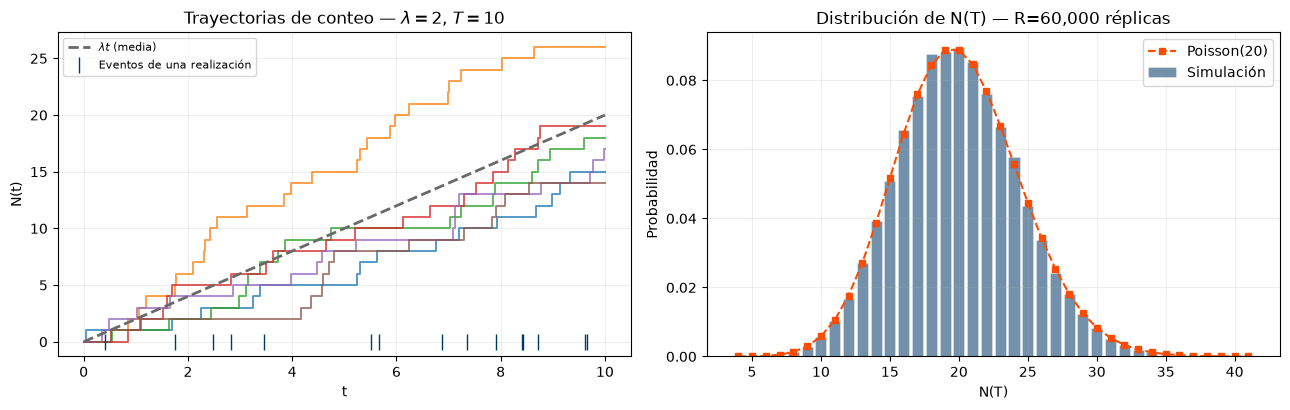

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Trayectoria de conteo de unas pocas realizaciones.
ax = axes[0]
for c in caminos6[:6]:
    ts = np.r_[0.0, c, T6]
    ns = np.r_[0, np.arange(1, c.size + 1), c.size]
    ax.step(ts, ns, where="post", alpha=.75, linewidth=1.4)
ax.plot([0, T6], [0, LAM6 * T6], linestyle="--", color=GREY, linewidth=2,
        label=r"$\lambda t$ (media)")
ax.plot(camino6, np.zeros_like(camino6), "|", color=NAVY, markersize=12,
        label="Eventos de una realización")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.set_title(f"Trayectorias de conteo — $\\lambda={LAM6:.0f}$, $T={T6:.0f}$")
ax.legend(fontsize=8)
ax.grid(alpha=.2)

# Distribución de N(T) contra Poisson(lambda T).
ax = axes[1]
k = np.arange(max(0, N6.min()), N6.max() + 1)
ax.bar(k, np.bincount(N6, minlength=k[-1] + 1)[k] / R6, color=NAVY, alpha=.55,
       edgecolor="white", linewidth=.4, label="Simulación")
ax.plot(k, stats.poisson.pmf(k, media_exacta), marker="s", markersize=4, linestyle="--",
        color=ORANGE, label=f"Poisson({media_exacta:.0f})")
ax.set_xlabel("N(T)")
ax.set_ylabel("Probabilidad")
ax.set_title(f"Distribución de N(T) — R={R6:,} réplicas")
ax.legend()
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

### Respuesta

El programa es `poisson_homogeneo(lam, T)`: acumula esperas $-\frac1\lambda\log U$ y se detiene al rebasar $T$. Con $\lambda=2$, $T=10$:

$$\boxed{N(T)\sim\text{Poisson}(\lambda T)=\text{Poisson}(20)},\qquad \boxed{E[N(T)]=\operatorname{Var}(N(T))=20}.$$

Las verificaciones pasan: la media y la varianza simuladas de $N(T)$ coinciden con $\lambda T$, la prueba chi-cuadrado no rechaza que los conteos sean Poisson(20), las esperas generadas no se distinguen de $\text{Exp}(2)$ y los tiempos de llegada son uniformes en $(0,10)$. Esta última es la propiedad de estadísticos de orden, y es la que confirma que el proceso no sólo tiene el número correcto de eventos sino que los coloca correctamente en el tiempo.

**Sobre la censura.** La tabla contrasta a propósito las dos formas de recolectar las esperas. Usando todas las generadas, la media es $0.5002$ y KS no rechaza. Quedándose sólo con las que caben dentro de $(0,T]$ —es decir, descartando la última, que es la que rebasa el horizonte— la media cae a $0.4753$, a **57 errores estándar** del valor correcto, y KS rechaza de forma contundente. No es un fallo del generador sino censura por la derecha: filtrar por "cabe en la ventana" elimina justamente las esperas largas. Es el mismo mecanismo que produce la paradoja de la inspección, y conviene tenerlo presente al validar cualquier simulación con horizonte fijo.

## 7. Ejercicio 7 — Proceso de Poisson no homogéneo por adelgazamiento

**Enunciado.** (a) Generar las primeras 10 unidades de tiempo de un Poisson no homogéneo con
$$\lambda(t)=3+\frac{4}{t+1}.$$
(b) Proponer una mejora del algoritmo de adelgazamiento para este ejemplo.

**(a) Método.** $\lambda$ es **decreciente**, así que su supremo en $[0,10]$ es $\lambda(0)=7$. Se simula un proceso homogéneo de tasa $\lambda^\*=7$ y cada candidato $t$ se conserva con probabilidad $\lambda(t)/\lambda^\*$:

- **Paso 1:** $t=0$.
- **Paso 2:** $t\leftarrow t-\frac{1}{\lambda^\*}\log U_1$; si $t>T$, terminar.
- **Paso 3:** generar $U_2$; si $U_2\le\lambda(t)/\lambda^\*$, aceptar $t$ como evento.
- **Paso 4:** volver al Paso 2.

**Valor exacto.** La media del proceso es
$$m(t)=\int_0^t\Bigl(3+\frac{4}{s+1}\Bigr)ds=3t+4\log(t+1),\qquad m(10)=30+4\log 11=39.5915811\ldots$$
y $N(10)\sim\text{Poisson}(m(10))$. El algoritmo propone $\lambda^\*T=70$ candidatos en promedio, así que **acepta sólo el $m(10)/70=56.6\%$**.

**(b) Mejora.** El desperdicio viene de usar la cota global $\lambda(0)=7$ durante todo el horizonte, cuando $\lambda$ ya ha caído a $3.36$ al final. Dos mejoras, de menor a mayor ambición:

1. **Adelgazamiento por tramos.** Partir $[0,10]$ en subintervalos y usar en cada uno su propia cota. Como $\lambda$ es decreciente, el supremo de cada tramo es su extremo izquierdo. Con los cortes $\{0,1,2,5,10\}$ las cotas son $\{7,\,5,\,4.33,\,3.67\}$ y el número esperado de candidatos baja de $70$ a $43.33$: la aceptación sube a $\mathbf{91.4\%}$. Refinando a $\{0,0.5,1,2,3,5,7,10\}$ se llega a $95.4\%$.
2. **Inversión de $m$, sin rechazo alguno.** Como $m$ es estrictamente creciente y continua, si $S_1<S_2<\cdots$ son los eventos de un Poisson **de tasa 1**, entonces $m^{-1}(S_1)<m^{-1}(S_2)<\cdots$ son los del proceso no homogéneo. Aquí $m(t)=3t+4\log(t+1)$ no tiene inversa elemental, pero se resuelve numéricamente con una precisión muy superior a la del muestreo. Cuesta exactamente $m(T)$ sorteos y **no rechaza nada**: es el límite de la idea del tramo cuando los tramos se hacen infinitesimales.

In [13]:
T7 = 10.0
lam7 = lambda t: 3 + 4 / (np.asarray(t, dtype=float) + 1)
m7 = lambda t: 3 * np.asarray(t, dtype=float) + 4 * np.log(np.asarray(t, dtype=float) + 1)

LAM_SUP7 = float(lam7(0.0))                 # lambda es decreciente: el sup global es lam(0)
assert LAM_SUP7 == 7.0
assert np.all(lam7(np.linspace(0, T7, 100_001)) <= LAM_SUP7)

m10 = float(m7(T7))
assert abs(m10 - (30 + 4 * math.log(11))) < 1e-12
assert abs(m10 - integrate.quad(lam7, 0, T7, epsabs=1e-14)[0]) < 1e-10


def thinning_global(T=T7):
    """(a) Adelgazamiento con la cota global lambda* = 7."""
    eventos, candidatos = [], 0
    t = 0.0                                             # Paso 1
    while True:
        t += -math.log(rng.random()) / LAM_SUP7         # Paso 2
        if t > T:
            return np.array(eventos), candidatos
        candidatos += 1
        if rng.random() <= lam7(t) / LAM_SUP7:          # Paso 3
            eventos.append(t)


CORTES7 = np.array([0.0, 1.0, 2.0, 5.0, 10.0])
COTAS7 = lam7(CORTES7[:-1])                 # decreciente: sup del tramo = extremo izquierdo
assert np.all(COTAS7 >= [lam7(np.linspace(a, b, 2000)).max()
                         for a, b in zip(CORTES7[:-1], CORTES7[1:])])


def thinning_tramos(cortes=CORTES7):
    """(b1) Adelgazamiento con una cota propia por tramo."""
    cotas = lam7(cortes[:-1])
    eventos, candidatos = [], 0
    for a, b, cota in zip(cortes[:-1], cortes[1:], cotas):
        t = a
        while True:
            t += -math.log(rng.random()) / cota
            if t > b:
                break
            candidatos += 1
            if rng.random() <= lam7(t) / cota:
                eventos.append(t)
    return np.array(eventos), candidatos


def inversion_m(T=T7):
    """(b2) Inversión de m: Poisson de tasa 1 en (0, m(T)] y t_i = m^{-1}(s_i). Sin rechazo."""
    s, esperas = 0.0, []
    while True:
        s += -math.log(rng.random())
        if s > m7(T):
            break
        esperas.append(s)
    return np.array([optimize.brentq(lambda t, y=y: m7(t) - y, 0.0, T) for y in esperas]), len(esperas)

# --- Comparación de los tres métodos -----------------------------------------
R7 = 20_000
resultados7 = {}
for nombre, fn in [("(a) Cota global 7", thinning_global),
                   ("(b1) Por tramos", thinning_tramos),
                   ("(b2) Inversión de m", inversion_m)]:
    Ns, cands, muestras = [], [], []
    for _ in range(R7):
        ev, c = fn()
        Ns.append(ev.size)
        cands.append(c)
        if len(muestras) < 400:
            muestras.append(ev)
    resultados7[nombre] = (np.array(Ns), np.array(cands, dtype=float), muestras)

filas = []
for nombre, (Ns, cands, _) in resultados7.items():
    est, se = Ns.mean(), se_media(Ns)
    acept = Ns.sum() / cands.sum()
    filas.append({"Método": nombre, "E[N(10)] MC": est, "SE": se, "E[N(10)] exacto": m10,
                  "Desviación (SE)": z_desviacion(est, m10, se),
                  "Candidatos/réplica": cands.mean(), "Aceptación": acept})
res7 = pd.DataFrame(filas)
res7["Aceptación exacta"] = [m10 / (LAM_SUP7 * T7),
                             m10 / float(np.sum(COTAS7 * np.diff(CORTES7))), 1.0]
display(tabla(res7, 5))
assert np.all(np.abs(res7["Desviación (SE)"]) < 4)

Método,E[N(10)] MC,SE,E[N(10)] exacto,Desviación (SE),Candidatos/réplica,Aceptación,Aceptación exacta
(a) Cota global 7,39.67490,0.04466,39.59158,1.86552,70.14420,0.56562,0.56559
(b1) Por tramos,39.60955,0.04477,39.59158,0.40133,43.32450,0.91425,0.91365
(b2) Inversión de m,39.58895,0.04497,39.59158,-0.05850,39.58895,1.00000,1.00000


In [14]:
# La prueba de fondo: los eventos deben reproducir lambda(t), no sólo su total.
eventos_todos = np.concatenate([e for e in resultados7["(a) Cota global 7"][2]])
R_muestra = len(resultados7["(a) Cota global 7"][2])
bordes = np.linspace(0, T7, 21)
conteo = np.histogram(eventos_todos, bins=bordes)[0]
esperado = np.array([integrate.quad(lam7, a, b)[0] for a, b in zip(bordes[:-1], bordes[1:])]) * R_muestra
se_conteo = np.sqrt(esperado)

int7 = pd.DataFrame({
    "Intervalo": [f"[{a:.1f}, {b:.1f})" for a, b in zip(bordes[:-1], bordes[1:])],
    "Eventos observados": conteo,
    "Esperados": esperado,
    "SE": se_conteo,
    "Desviación (SE)": (conteo - esperado) / se_conteo,
})
display(tabla(int7.head(10), 4))
chi7 = stats.chisquare(conteo, esperado * conteo.sum() / esperado.sum())
print(f"Chi-cuadrado de la intensidad por tramos: X2 = {chi7.statistic:.2f}, p = {chi7.pvalue:.4f}")
print(f"Máxima desviación estandarizada: {np.abs(int7['Desviación (SE)']).max():.2f} SE")

Intervalo,Eventos observados,Esperados,SE,Desviación (SE)
"[0.0, 0.5)","1,257","1,248.7442",35.3376,0.2336
"[0.5, 1.0)","1,043","1,060.2913",32.5621,-0.5310
"[1.0, 1.5)",958,957.0297,30.9359,0.0314
"[1.5, 2.0)",905,891.7145,29.8616,0.4449
"[2.0, 2.5)",867,846.6411,29.0971,0.6997
"[2.5, 3.0)",849,813.6502,28.5246,1.2393
"[3.0, 3.5)",810,788.4529,28.0794,0.7674
"[3.5, 4.0)",745,768.5768,27.7232,-0.8504
"[4.0, 4.5)",696,752.4963,27.4317,-2.0595
"[4.5, 5.0)",721,739.2182,27.1886,-0.6701


Chi-cuadrado de la intensidad por tramos: X2 = 17.68, p = 0.5441
Máxima desviación estandarizada: 2.06 SE


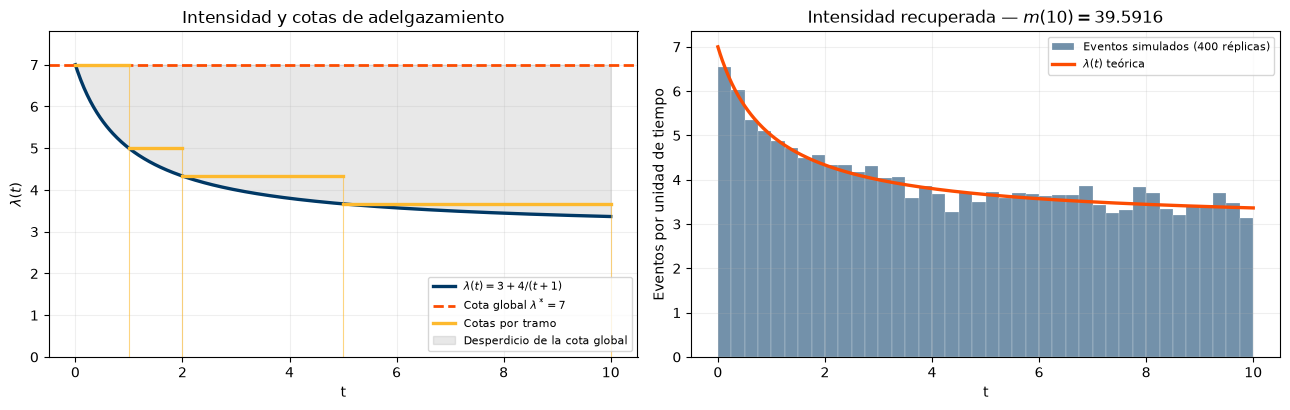

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Intensidad, cota global y cotas por tramo.
ax = axes[0]
ts = np.linspace(0, T7, 500)
ax.plot(ts, lam7(ts), color=NAVY, linewidth=2.4, label=r"$\lambda(t)=3+4/(t+1)$")
ax.axhline(LAM_SUP7, color=ORANGE, linestyle="--", linewidth=2,
           label=f"Cota global $\\lambda^*={LAM_SUP7:.0f}$")
for a, b, cota in zip(CORTES7[:-1], CORTES7[1:], COTAS7):
    ax.plot([a, b], [cota, cota], color=YELLOW, linewidth=2.4)
    ax.plot([b, b], [0, cota], color=YELLOW, linewidth=.8, alpha=.6)
ax.plot([], [], color=YELLOW, linewidth=2.4, label="Cotas por tramo")
ax.fill_between(ts, lam7(ts), LAM_SUP7, color=GREY, alpha=.15, label="Desperdicio de la cota global")
ax.set_ylim(0, 7.8)
ax.set_xlabel("t")
ax.set_ylabel(r"$\lambda(t)$")
ax.set_title("Intensidad y cotas de adelgazamiento")
ax.legend(fontsize=8)
ax.grid(alpha=.2)

# Densidad empírica de los eventos contra lambda(t).
ax = axes[1]
ax.hist(eventos_todos, bins=40, weights=np.full(eventos_todos.size, 40 / (T7 * R_muestra)),
        color=NAVY, alpha=.55, edgecolor="white", linewidth=.3,
        label=f"Eventos simulados ({R_muestra} réplicas)")
ax.plot(ts, lam7(ts), color=ORANGE, linewidth=2.4, label=r"$\lambda(t)$ teórica")
ax.set_xlabel("t")
ax.set_ylabel("Eventos por unidad de tiempo")
ax.set_title(f"Intensidad recuperada — $m(10)={m10:.4f}$")
ax.legend(fontsize=8)
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

### Respuesta

**(a)** `thinning_global` genera el proceso con la cota $\lambda^\*=\lambda(0)=7$. El número de eventos en $[0,10]$ es Poisson con media
$$\boxed{m(10)=30+4\log 11=39.5915811\ldots}$$
y la simulación lo reproduce dentro del error Monte Carlo. La verificación fuerte es la tabla de intensidad: los eventos observados por subintervalo coinciden con $\int_a^b\lambda(t)\,dt$, así que el proceso tiene la forma temporal correcta y no sólo el total correcto. Su costo es de $\lambda^\*T=70$ candidatos por réplica, de los que sólo se acepta el $\boxed{56.6\%}$.

**(b) Mejoras.**

1. **Por tramos:** usar la cota local de cada subintervalo. Con los cortes $\{0,1,2,5,10\}$ los candidatos esperados bajan de $70$ a $43.33$ y la aceptación sube a $\boxed{91.4\%}$ —menos de la mitad de trabajo desperdiciado— sin cambiar en nada la distribución generada, como confirma que las tres estimaciones de $E[N(10)]$ coincidan.
2. **Inversión de $m$:** generar un Poisson de tasa 1 en $(0,m(10)]$ y aplicar $m^{-1}$. **Cero rechazos**, exactamente $m(10)\approx 39.6$ sorteos. Es lo mejor posible y aquí es viable porque $m(t)=3t+4\log(t+1)$ es estrictamente creciente e invertible numéricamente.

La primera gráfica explica visualmente de dónde sale la ganancia: el área gris entre $\lambda(t)$ y la cota global es exactamente el trabajo tirado, y los escalones amarillos la recortan.